In [137]:
import pandas as pd
import warnings


In [138]:
warnings.filterwarnings("ignore")

In [139]:
df = pd.read_excel("HotelData.xlsx")

In [140]:
df

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,224,2017,10,2,0,0,0,65.00,0,Not_Canceled
1,2,0,2,3,Not Selected,0,5,2018,11,6,0,0,0,106.68,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0,1,2018,2,28,0,0,0,60.00,0,Canceled
3,2,0,0,2,Meal Plan 1,0,211,2018,5,20,0,0,0,100.00,0,Canceled
4,2,0,1,1,Not Selected,0,48,2018,4,11,0,0,0,94.50,0,Canceled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25806,2,2,0,1,Meal Plan 1,0,0,2018,10,6,0,0,0,216.00,0,Canceled
25807,3,0,2,6,Meal Plan 1,0,85,2018,8,3,0,0,0,167.80,1,Not_Canceled
25808,2,0,1,3,Meal Plan 1,0,228,2018,10,17,0,0,0,90.95,2,Canceled
25809,2,0,2,6,Meal Plan 1,0,148,2018,7,1,0,0,0,98.39,2,Not_Canceled


In [141]:
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,224,2017,10,2,0,0,0,65.00,0,Not_Canceled
1,2,0,2,3,Not Selected,0,5,2018,11,6,0,0,0,106.68,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0,1,2018,2,28,0,0,0,60.00,0,Canceled
3,2,0,0,2,Meal Plan 1,0,211,2018,5,20,0,0,0,100.00,0,Canceled
4,2,0,1,1,Not Selected,0,48,2018,4,11,0,0,0,94.50,0,Canceled


In [142]:
df["total_guests"] = df["no_of_adults"] +df["no_of_children"]

In [143]:
df.head()


,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,total_guests
0,2,0,1,2,Meal Plan 1,0,224,2017,10,2,0,0,0,65.00,0,Not_Canceled,2
1,2,0,2,3,Not Selected,0,5,2018,11,6,0,0,0,106.68,1,Not_Canceled,2
2,1,0,2,1,Meal Plan 1,0,1,2018,2,28,0,0,0,60.00,0,Canceled,1
3,2,0,0,2,Meal Plan 1,0,211,2018,5,20,0,0,0,100.00,0,Canceled,2
4,2,0,1,1,Not Selected,0,48,2018,4,11,0,0,0,94.50,0,Canceled,2


In [144]:
df["total_nights"] = df["no_of_weekend_nights"] +df["no_of_week_nights"]

In [145]:
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,total_guests,total_nights
0,2,0,1,2,Meal Plan 1,0,224,2017,10,2,0,0,0,65.00,0,Not_Canceled,2,3
1,2,0,2,3,Not Selected,0,5,2018,11,6,0,0,0,106.68,1,Not_Canceled,2,5
2,1,0,2,1,Meal Plan 1,0,1,2018,2,28,0,0,0,60.00,0,Canceled,1,3
3,2,0,0,2,Meal Plan 1,0,211,2018,5,20,0,0,0,100.00,0,Canceled,2,2
4,2,0,1,1,Not Selected,0,48,2018,4,11,0,0,0,94.50,0,Canceled,2,2


In [146]:
df["booking_status"].value_counts(normalize=True)

booking_status
Not_Canceled    0.718376
Canceled        0.281624
Name: proportion, dtype: float64

In [147]:
import seaborn as sns
import matplotlib.pyplot as plt

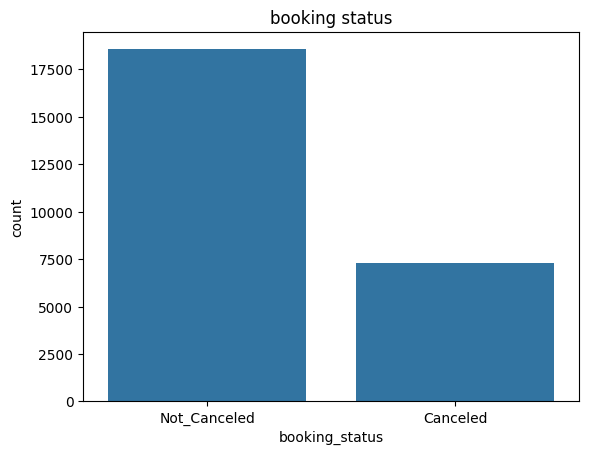

In [148]:
sns.countplot(data = df,x="booking_status")
plt.title("booking status")
plt.show()

In [149]:
num_cols=df.select_dtypes(include=["int64","float64"]).columns

In [150]:
num_cols

Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'required_car_parking_space', 'lead_time',
       'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests', 'total_guests',
       'total_nights'],
      dtype='str')

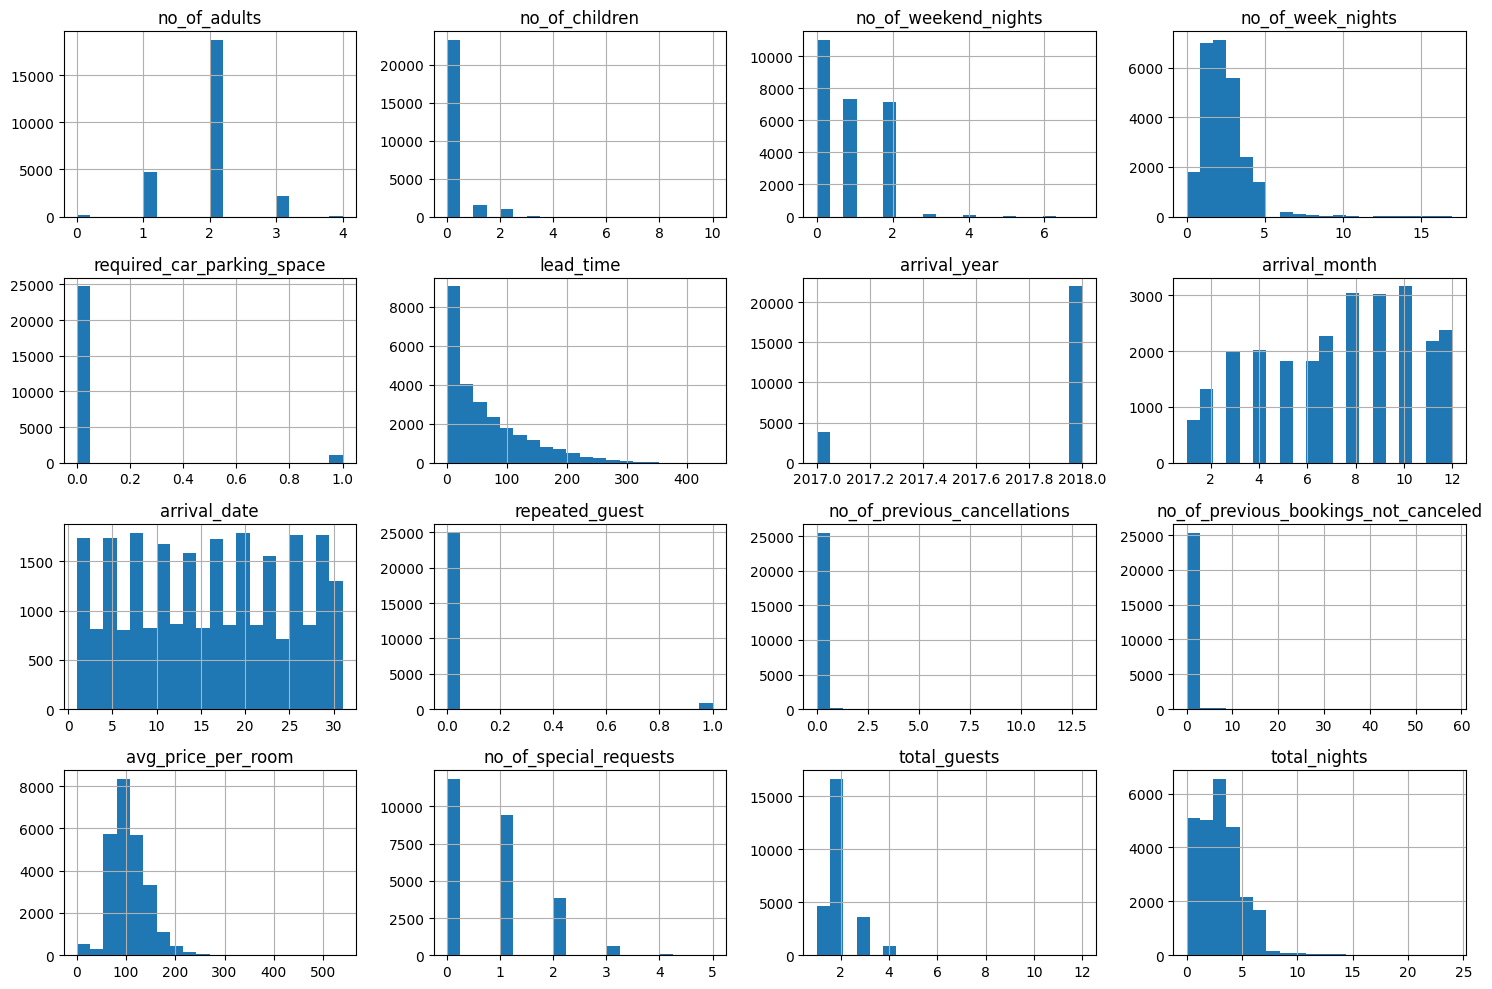

In [151]:
df[num_cols].hist(figsize=(15,10),bins=20)
plt.tight_layout()
plt.show()

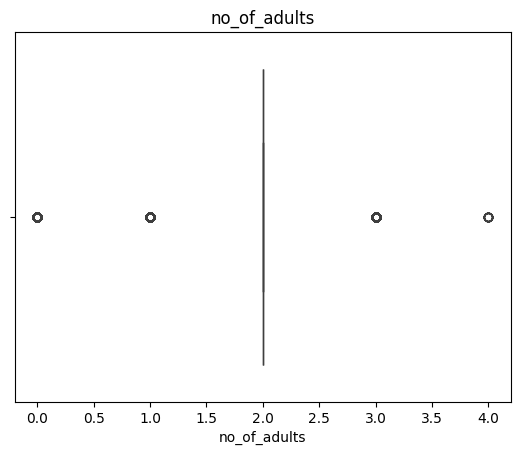

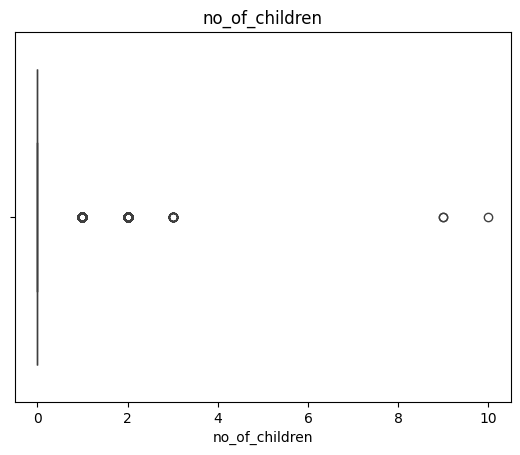

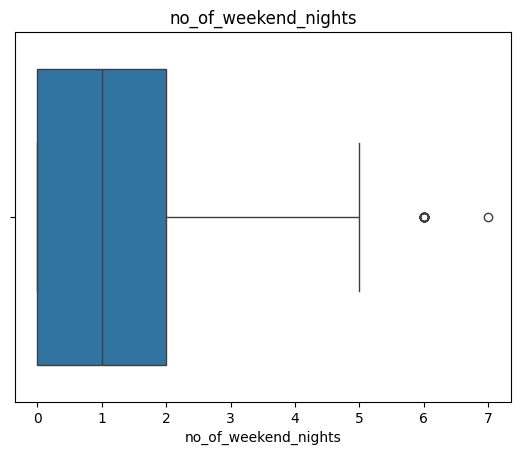

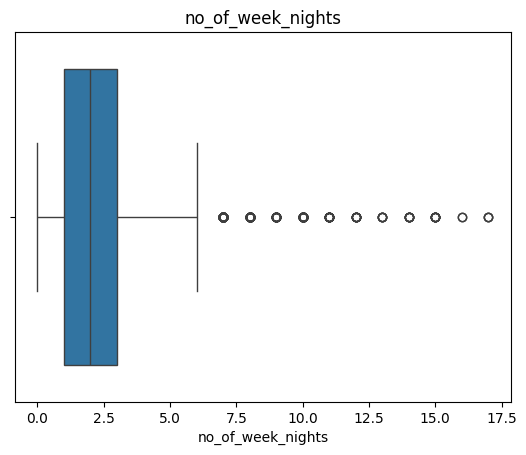

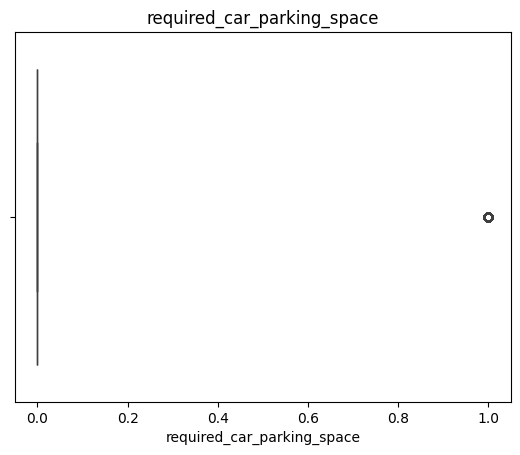

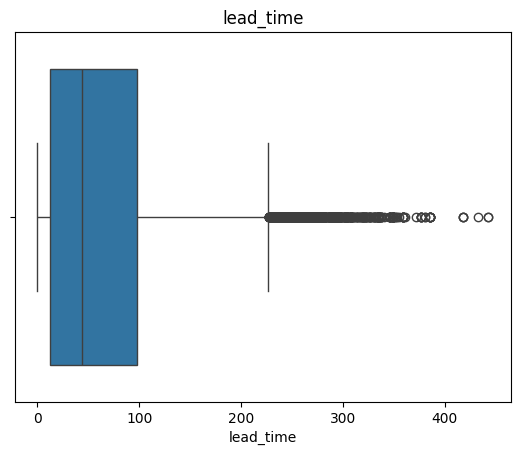

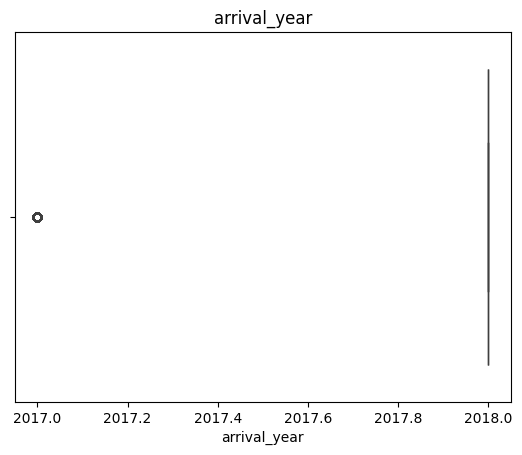

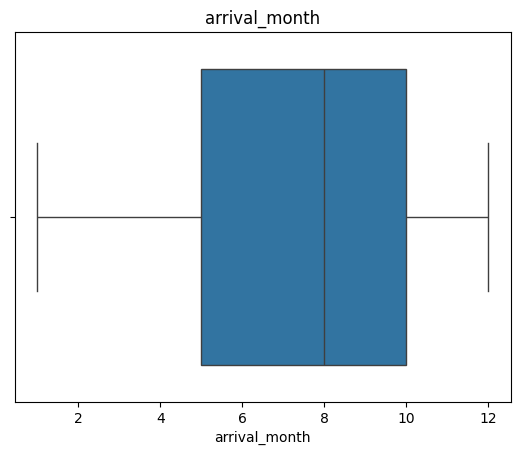

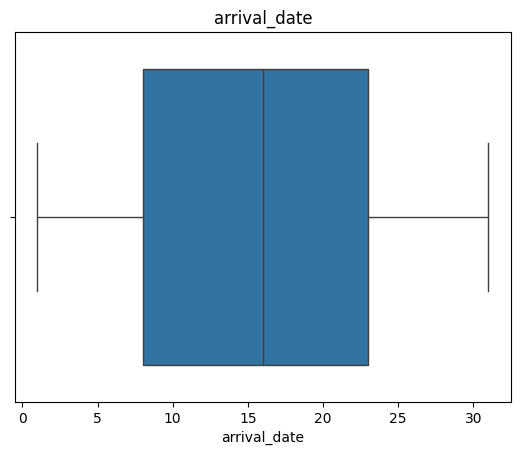

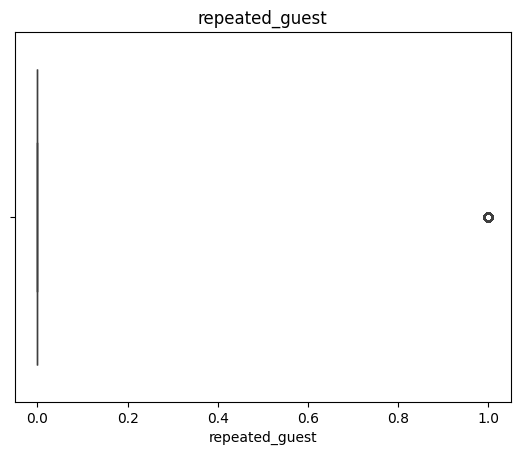

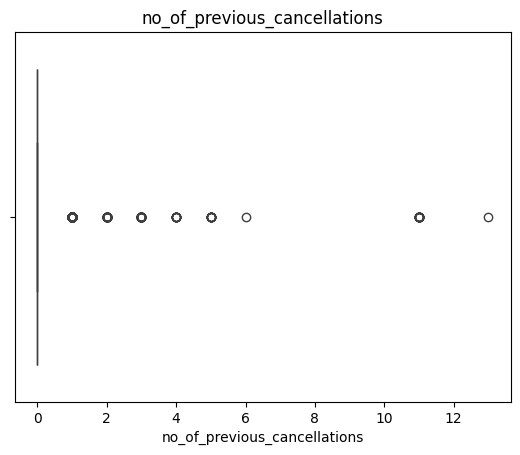

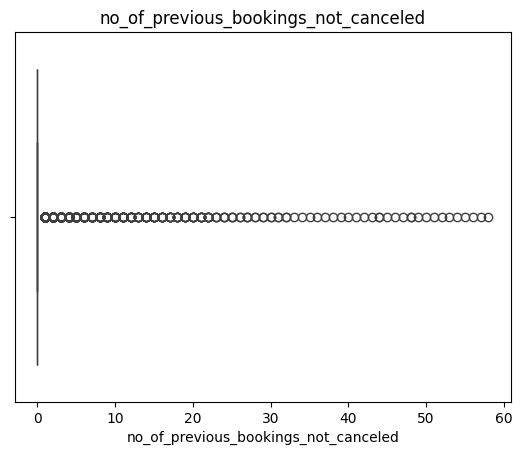

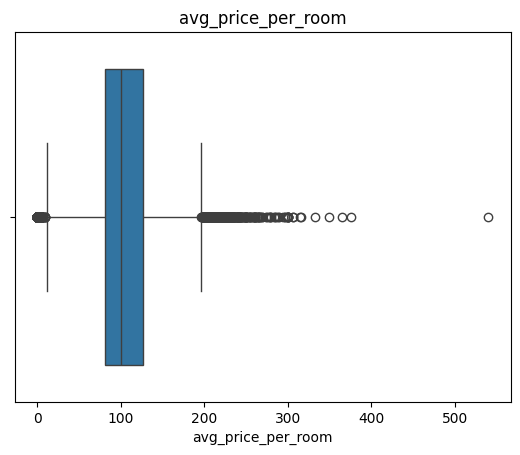

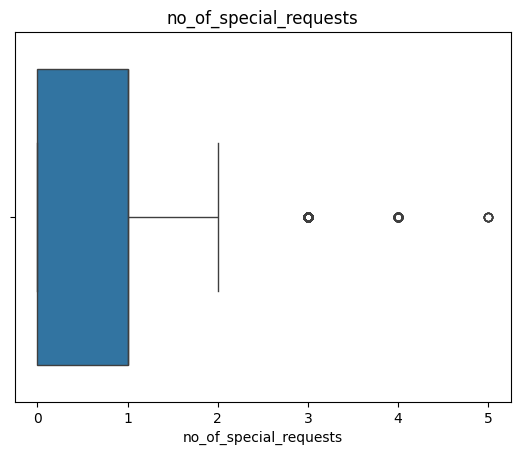

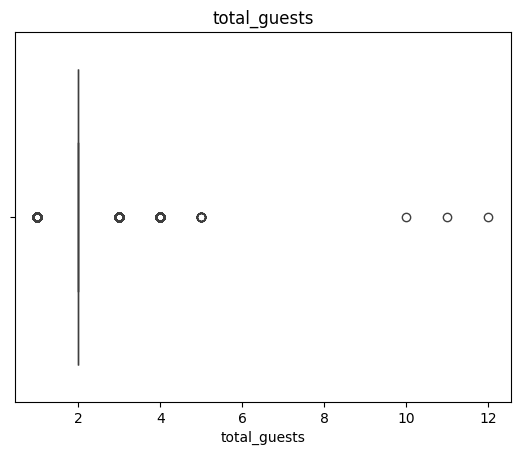

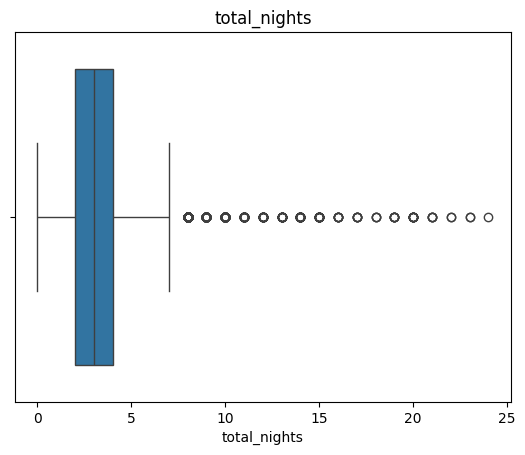

In [152]:
for col in num_cols:
    plt.Figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()


In [153]:
df.groupby("booking_status")["lead_time"].mean()

booking_status
Canceled        104.366488
Not_Canceled     50.331194
Name: lead_time, dtype: float64

In [154]:
df.groupby("booking_status")["avg_price_per_room"].mean()

booking_status
Canceled        115.347719
Not_Canceled    101.984183
Name: avg_price_per_room, dtype: float64

In [155]:
df.groupby("booking_status")["total_guests"].mean()

booking_status
Canceled        2.163434
Not_Canceled    1.981879
Name: total_guests, dtype: float64

In [156]:
df.groupby(["type_of_meal_plan","booking_status"]).size().unstack()

booking_status,Canceled,Not_Canceled
type_of_meal_plan,,
Meal Plan 1,5500,14765
Meal Plan 2,368,710
Meal Plan 3,1,4
Not Selected,1400,3063


In [157]:
pivot_price = pd.pivot_table(
    df,
    values = "avg_price_per_room",
    index = "arrival_month",
    columns = "booking_status",
    aggfunc="mean"
)



In [158]:
pivot_price

booking_status,Canceled,Not_Canceled
arrival_month,,
1,80.712500,74.699604
2,85.791088,81.922206
3,102.712011,88.245341
4,114.445248,101.441568
5,127.641138,114.316431
6,121.214241,110.758705
7,116.580144,113.607542
8,120.482596,113.883753
9,128.644103,116.043386


In [159]:
pd.pivot_table(
    df,
    values = "no_of_adults",
    index = "arrival_month",
    columns = "booking_status",
    aggfunc= "count"

)

booking_status,Canceled,Not_Canceled
arrival_month,,
1,16,758
2,285,1029
3,542,1436
4,625,1397
5,571,1261
6,573,1251
7,903,1371
8,1198,1844
9,853,2168


In [160]:
cancel_rate = df.groupby("arrival_month")["booking_status"].apply(
    lambda x: (x == "Canceled").mean()
)

In [161]:
cancel_rate

arrival_month
1     0.020672
2     0.216895
3     0.274014
4     0.309100
5     0.311681
6     0.314145
7     0.397098
8     0.393820
9     0.282357
10    0.276178
11    0.224154
12    0.142677
Name: booking_status, dtype: float64

<Axes: title={'center': 'cancellation rate by month'}, xlabel='arrival_month'>

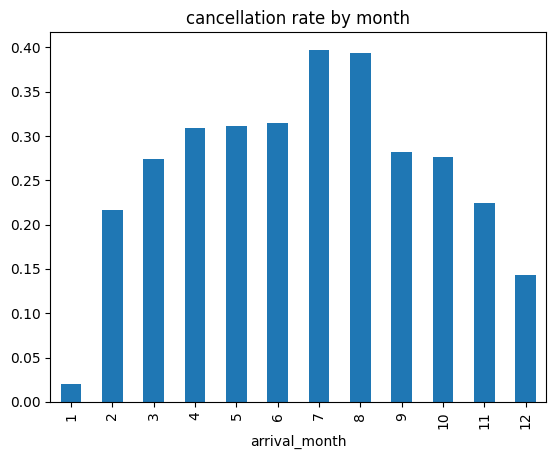

In [162]:
cancel_rate.plot(kind="bar",title="cancellation rate by month")

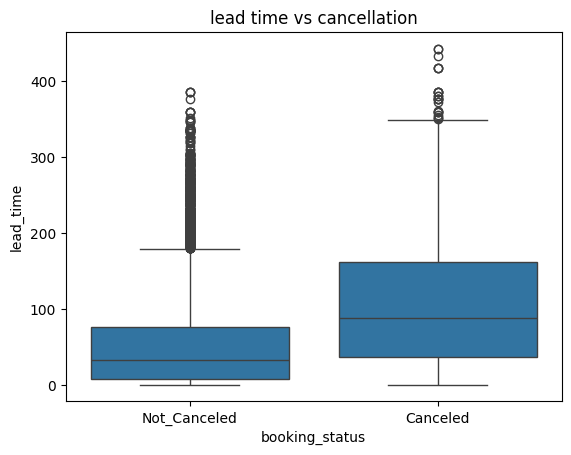

In [163]:
sns.boxplot(data=df,x="booking_status",y="lead_time")
plt.title("lead time vs cancellation")
plt.show()

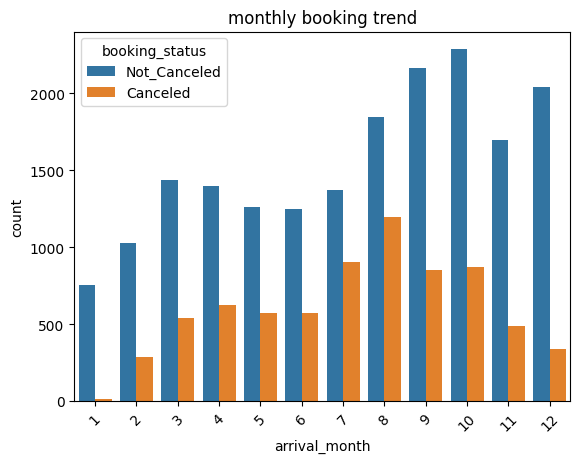

In [164]:
sns.countplot(data=df,x="arrival_month",hue="booking_status")
plt.title("monthly booking trend")
plt.xticks(rotation=45)
plt.show()


In [165]:
df = pd.read_excel("HotelData.xlsx")


In [166]:
print(df["booking_status"].unique())

<StringArray>
['Not_Canceled', 'Canceled']
Length: 2, dtype: str


In [167]:
df["booking_status"] = df["booking_status"].replace({
    "Not_Canceled": 1,
    "Canceled": 0
})

print(df["booking_status"].head())

0    1
1    1
2    0
3    0
4    0
Name: booking_status, dtype: object


In [168]:
df

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,224,2017,10,2,0,0,0,65.00,0,1
1,2,0,2,3,Not Selected,0,5,2018,11,6,0,0,0,106.68,1,1
2,1,0,2,1,Meal Plan 1,0,1,2018,2,28,0,0,0,60.00,0,0
3,2,0,0,2,Meal Plan 1,0,211,2018,5,20,0,0,0,100.00,0,0
4,2,0,1,1,Not Selected,0,48,2018,4,11,0,0,0,94.50,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25806,2,2,0,1,Meal Plan 1,0,0,2018,10,6,0,0,0,216.00,0,0
25807,3,0,2,6,Meal Plan 1,0,85,2018,8,3,0,0,0,167.80,1,1
25808,2,0,1,3,Meal Plan 1,0,228,2018,10,17,0,0,0,90.95,2,0
25809,2,0,2,6,Meal Plan 1,0,148,2018,7,1,0,0,0,98.39,2,1


In [169]:
df["is_weekend_heavy"]=(df["no_of_weekend_nights"]>df["no_of_week_nights"]).astype(int)
df

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,is_weekend_heavy
0,2,0,1,2,Meal Plan 1,0,224,2017,10,2,0,0,0,65.00,0,1,0
1,2,0,2,3,Not Selected,0,5,2018,11,6,0,0,0,106.68,1,1,0
2,1,0,2,1,Meal Plan 1,0,1,2018,2,28,0,0,0,60.00,0,0,1
3,2,0,0,2,Meal Plan 1,0,211,2018,5,20,0,0,0,100.00,0,0,0
4,2,0,1,1,Not Selected,0,48,2018,4,11,0,0,0,94.50,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25806,2,2,0,1,Meal Plan 1,0,0,2018,10,6,0,0,0,216.00,0,0,0
25807,3,0,2,6,Meal Plan 1,0,85,2018,8,3,0,0,0,167.80,1,1,0
25808,2,0,1,3,Meal Plan 1,0,228,2018,10,17,0,0,0,90.95,2,0,0
25809,2,0,2,6,Meal Plan 1,0,148,2018,7,1,0,0,0,98.39,2,1,0


In [170]:
df.columns

Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'lead_time', 'arrival_year', 'arrival_month', 'arrival_date',
       'repeated_guest', 'no_of_previous_cancellations',
       'no_of_previous_bookings_not_canceled', 'avg_price_per_room',
       'no_of_special_requests', 'booking_status', 'is_weekend_heavy'],
      dtype='str')

In [171]:
features = [
    "lead_time",
    "avg_price_per_room",
    "no_of_special_requests",
    "total_guests",
    "total_nights",
    "repeated_guest"
]

In [172]:
df["total_guests"] = df["no_of_adults"] + df["no_of_children"]

df["total_nights"] = (
    df["no_of_weekend_nights"] +
    df["no_of_week_nights"]
)

In [173]:
X = df[features]

In [174]:
y=df["booking_status"]

In [175]:
X

,lead_time,avg_price_per_room,no_of_special_requests,total_guests,total_nights,repeated_guest
0,224,65.00,0,2,3,0
1,5,106.68,1,2,5,0
2,1,60.00,0,1,3,0
3,211,100.00,0,2,2,0
4,48,94.50,0,2,2,0
...,...,...,...,...,...,...
25806,0,216.00,0,4,1,0
25807,85,167.80,1,3,8,0
25808,228,90.95,2,2,4,0
25809,148,98.39,2,2,8,0


In [176]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [177]:
from sklearn.model_selection import train_test_split

In [178]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y)

In [179]:
y.value_counts()

booking_status
1    18542
0     7269
Name: count, dtype: int64

In [180]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes=np.unique(y_train)

In [181]:
classes

array([0, 1], dtype=object)

In [182]:
weights = compute_class_weight(class_weight="balanced", classes= classes,y=y_train)

In [183]:
weights

array([1.77540843, 0.69601564])

In [184]:
class_weights=dict(zip(classes,weights))

In [185]:
class_weights

{0: np.float64(1.775408426483233), 1: np.float64(0.6960156408009168)}

In [186]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

In [187]:
rf=RandomForestClassifier(class_weight=class_weights)

In [188]:
rf_params={
    "n_estimators":[100, 200, 300],
    "max_depth" : [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf" : [1, 2, 4]
}

In [189]:
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=20,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

In [190]:
print(df["booking_status"].unique())

[1 0]


In [191]:
print(df["booking_status"].dtype)

object


In [192]:
df["booking_status"] = df["booking_status"].astype(int)

In [193]:
print(df["booking_status"].dtype)

int64


In [194]:
X = df[features]
y = df["booking_status"]

In [195]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [196]:
rf_random.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...56408009168)})
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_mode

In [197]:
rf_random.best_params_

{'n_estimators': 300,
 'min_samples_split': 5,
 'min_samples_leaf': 2,
 'max_depth': 10}

In [198]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()

In [199]:
gb_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 5, 7]
}

In [200]:
gb_random = RandomizedSearchCV(
    gb,
    gb_params,
    n_iter=15,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

In [201]:
gb_random.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoostingClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_calla

In [202]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight=class_weights[0] / class_weights[1],
    eval_metric="logloss"
)

In [203]:
xgb_params ={

    "n_estimators": [100, 200, 300],
    "max_depth" : [ 3,5,7],
    "learning_rate" : [0.01, 0.1, 0.2],
    "subsample": [0.7, 1.0],
    "colsample_bytree" : [0.7, 1.0]
}

In [204]:
xgb_random=RandomizedSearchCV(
    xgb,
    xgb_params,
    n_iter=20,
    cv=3,
    scoring="accuracy",
    n_jobs=-1

)

In [205]:
xgb_random.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 1.0], 'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_example

In [206]:
from sklearn.metrics import accuracy_score

In [207]:
from sklearn.ensemble import RandomForestClassifier

best_rf = RandomForestClassifier(
    n_estimators=300,
    min_samples_split=5,
    min_samples_leaf=2,
    max_depth=10,
    random_state=42
)

best_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

In [208]:
models = {
    "Random Forest": best_rf,
    "Gradient Boosting": gb_random.best_estimator_,
    "XGBoost": xgb
}

In [209]:
xgb.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [210]:
for name, model in models.items():
    print(name)
    y_pred = model.predict(X_test)
    print(accuracy_score(y_test, y_pred))

Random Forest
0.8227774549680419
Gradient Boosting
0.8295564594228162
XGBoost
0.8036025566531086


In [211]:
import joblib

best_model=gb_random.best_estimator_

In [212]:
joblib.dump(best_model,"gb_booking_model.pkl")

['gb_booking_model.pkl']

In [213]:
features

['lead_time',
 'avg_price_per_room',
 'no_of_special_requests',
 'total_guests',
 'total_nights',
 'repeated_guest']

In [214]:
import joblib

joblib.dump(gb_random.best_estimator_, "gb_booking_model.pkl")

['gb_booking_model.pkl']